### Imports

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder

### Configurations

In [87]:
data_path = "data/main.csv"

## Exploratory Data Analysis

In [88]:
db_main = pd.read_csv(data_path)
db_main.head()

,health_service_area,hospital_county,operating_certificate_number,facility_id,facility_name,age_group,zip_code_3_digits,gender,race,ethnicity,...,apr_risk_of_mortality,apr_medical_surgical_description,payment_typology_1,birth_weight,abortion_edit_indicator,emergency_department_indicator,total_charges,total_costs,payment_typology_2,payment_typology_3
0,New York City,Bronx,7000001,1164,Bronx-Lebanon Hospital Center - Fulton Division,30 to 49,114,M,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,8225.00,7341.60,NaN,NaN
1,New York City,Bronx,7000002,1165,Jacobi Medical Center,30 to 49,104,M,Black/African American,Not Span/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,4846.76,2801.79,NaN,NaN
2,New York City,Bronx,7000002,1165,Jacobi Medical Center,0 to 17,104,M,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,17205.30,9945.95,Medicaid,NaN
3,New York City,Bronx,7000002,1165,Jacobi Medical Center,30 to 49,104,F,Black/African American,Not Span/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,9132.22,5279.11,NaN,NaN
4,New York City,Bronx,7000002,1165,Jacobi Medical Center,0 to 17,104,F,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,6645.30,3841.48,NaN,NaN


In [89]:
print(db_main.shape)

(10000, 34)


In [90]:
db_main.describe()

,operating_certificate_number,facility_id,discharge_year,ccs_diagnosis_code,ccs_procedure_code,apr_drg_code,apr_mdc_code,apr_severity_of_illness_code,birth_weight,total_charges,total_costs
count,1.000000e+04,10000.0000,10000.0,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04
mean,7.000002e+06,1164.5540,2016.0,422.75140,158.494900,589.99610,14.952700,1.932200,171.630000,2.970599e+04,1.982448e+04
std,4.971003e-01,0.4971,0.0,256.73377,92.660328,249.79592,6.389597,0.719065,727.732851,1.023361e+05,6.051160e+04
min,7.000001e+06,1164.0000,2016.0,1.00000,0.000000,4.00000,1.000000,1.000000,0.000000,1.120000e+03,6.474400e+02
25%,7.000001e+06,1164.0000,2016.0,181.00000,80.000000,384.00000,9.000000,1.000000,0.000000,7.304615e+03,6.138343e+03
50%,7.000002e+06,1165.0000,2016.0,657.00000,218.000000,750.00000,19.000000,2.000000,0.000000,1.404089e+04,9.412990e+03
75%,7.000002e+06,1165.0000,2016.0,659.00000,219.000000,770.00000,20.000000,2.000000,0.000000,2.780668e+04,1.938929e+04
max,7.000002e+06,1165.0000,2016.0,917.00000,999.000000,952.00000,25.000000,4.000000,4700.000000,5.031496e+06,2.908582e+06


In [91]:
db_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   health_service_area                  10000 non-null  str    
 1   hospital_county                      10000 non-null  str    
 2   operating_certificate_number         10000 non-null  int64  
 3   facility_id                          10000 non-null  int64  
 4   facility_name                        10000 non-null  str    
 5   age_group                            10000 non-null  str    
 6   zip_code_3_digits                    9841 non-null   str    
 7   gender                               10000 non-null  str    
 8   race                                 10000 non-null  str    
 9   ethnicity                            10000 non-null  str    
 10  length_of_stay                       10000 non-null  str    
 11  type_of_admission                    100

In [92]:
columns_for_the_table = [
    "health_service_area", 
    "age_group", 
    "gender", 
    "race", 
    "type_of_admission", 
    "patient_disposition", 
    "ccs_diagnosis_code", 
    "ccs_procedure_code", 
    "apr_drg_code", 
    "apr_mdc_code", 
    "apr_severity_of_illness_code", 
    "apr_risk_of_mortality", 
    "birth_weight", 
    "abortion_edit_indicator", 
    "emergency_department_indicator", 
    "length_of_stay"
]

### Selecting the features which are intuitively more important for the model and removing non relevant ones like payment and description features.

In [93]:
db = db_main[columns_for_the_table]
db.head()

,health_service_area,age_group,gender,race,type_of_admission,patient_disposition,ccs_diagnosis_code,ccs_procedure_code,apr_drg_code,apr_mdc_code,apr_severity_of_illness_code,apr_risk_of_mortality,birth_weight,abortion_edit_indicator,emergency_department_indicator,length_of_stay
0,New York City,30 to 49,M,Other Race,Emergency,Home or Self Care,657,0,753,19,1,Minor,0,N,Y,3
1,New York City,30 to 49,M,Black/African American,Emergency,Home or Self Care,657,218,753,19,1,Minor,0,N,Y,3
2,New York City,0 to 17,M,Other Race,Emergency,Home or Self Care,128,231,141,4,2,Minor,0,N,Y,3
3,New York City,30 to 49,F,Black/African American,Emergency,Home or Self Care,657,218,753,19,1,Minor,0,N,Y,6
4,New York City,0 to 17,F,Other Race,Emergency,Home or Self Care,128,231,141,4,1,Minor,0,N,Y,1


### Check Null Values

In [94]:
db.isna().sum()

health_service_area               0
age_group                         0
gender                            0
race                              0
type_of_admission                 0
patient_disposition               0
ccs_diagnosis_code                0
ccs_procedure_code                0
apr_drg_code                      0
apr_mdc_code                      0
apr_severity_of_illness_code      0
apr_risk_of_mortality             0
birth_weight                      0
abortion_edit_indicator           0
emergency_department_indicator    0
length_of_stay                    0
dtype: int64

### Check the destribution of each feature

### Destribution of categorical data

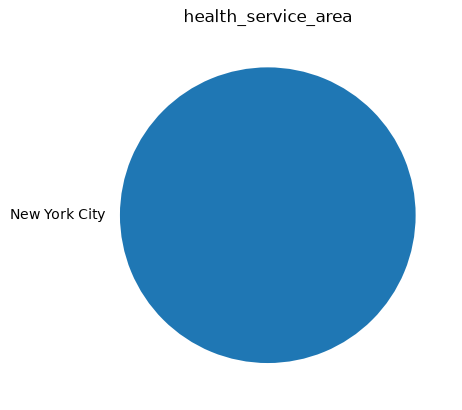

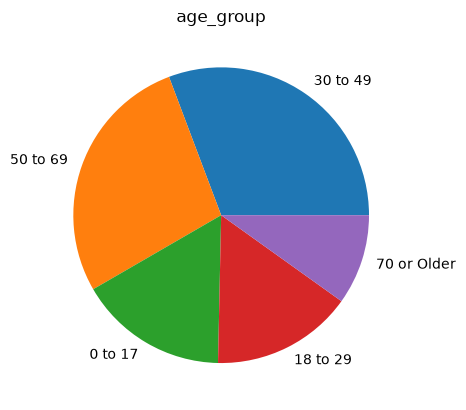

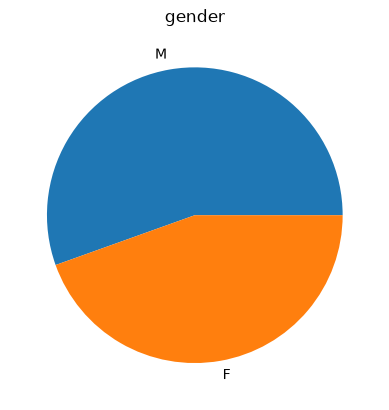

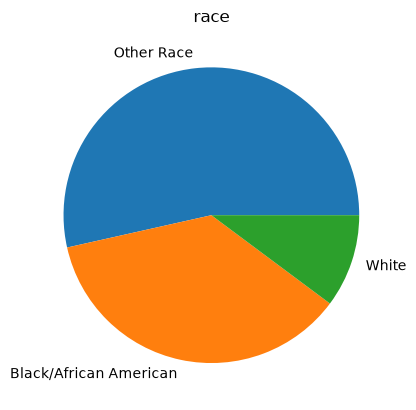

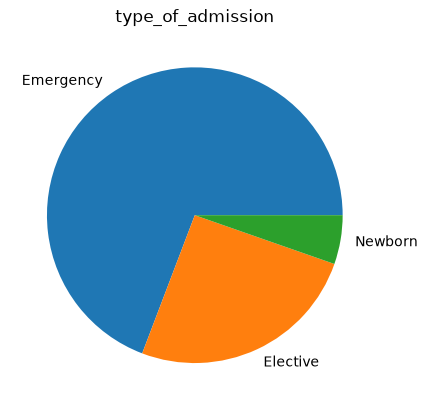

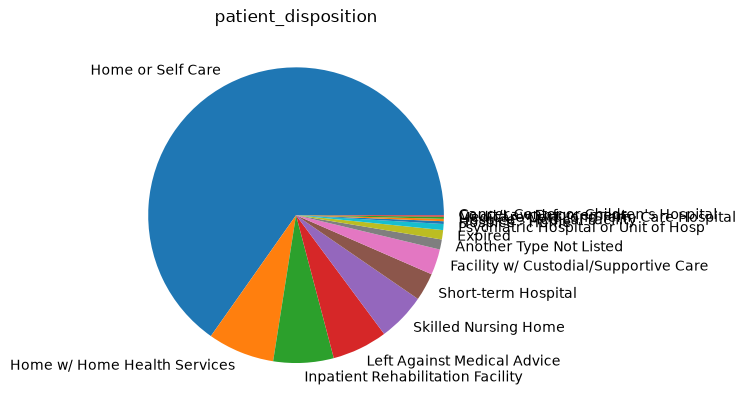

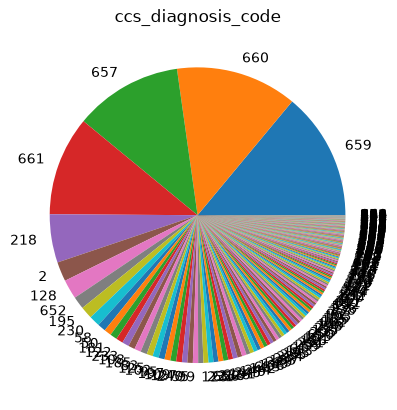

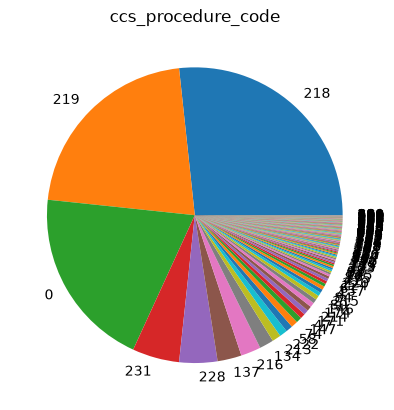

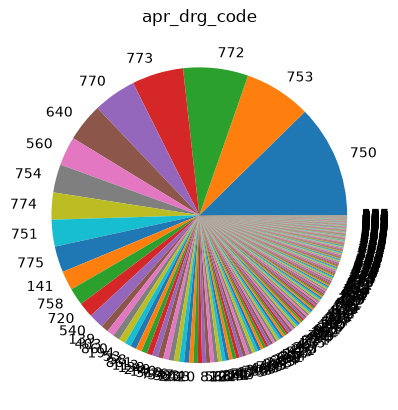

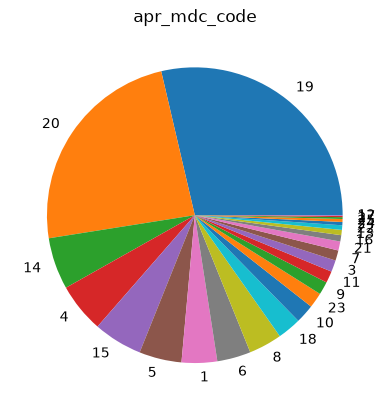

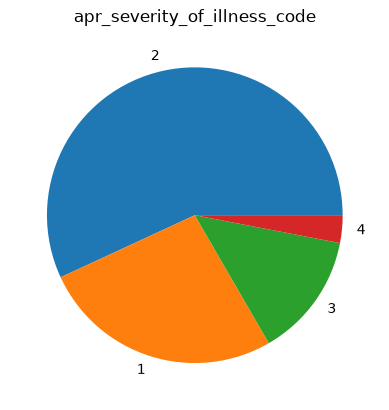

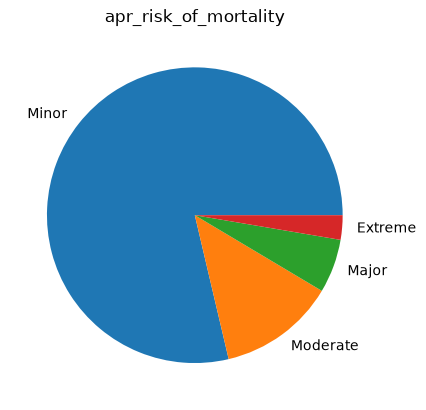

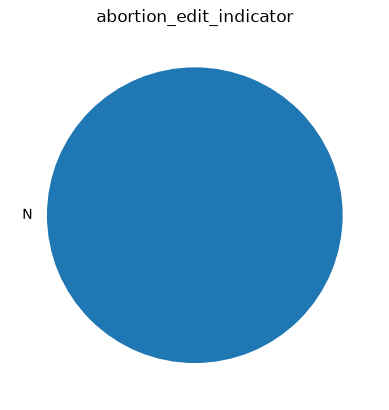

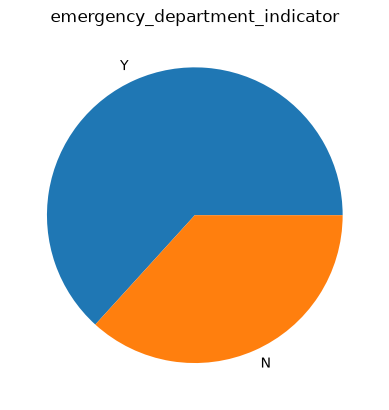

In [95]:
plots_to_make = [
    "health_service_area",
    "age_group",
    "gender",
    "race",
    "type_of_admission",
    "patient_disposition",
    "ccs_diagnosis_code",
    "ccs_procedure_code",
    "apr_drg_code",
    "apr_mdc_code",
    "apr_severity_of_illness_code",
    "apr_risk_of_mortality",
    "abortion_edit_indicator",
    "emergency_department_indicator"
]
for i in plots_to_make:
    counts_for_hs = db[i].value_counts()
    labels = counts_for_hs.index
    values = counts_for_hs.values

# Plot the chart
    plt.pie(values, labels=labels)
    plt.title(i)
    plt.show()

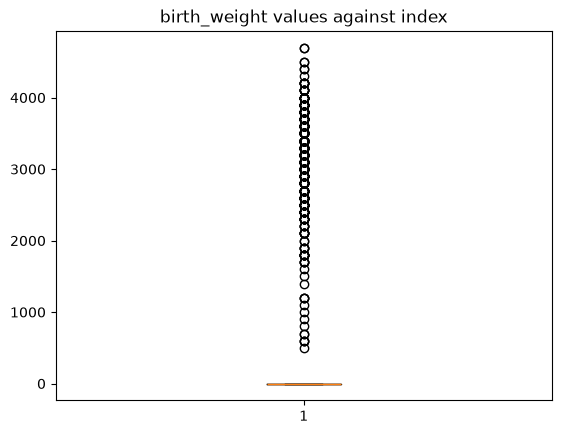

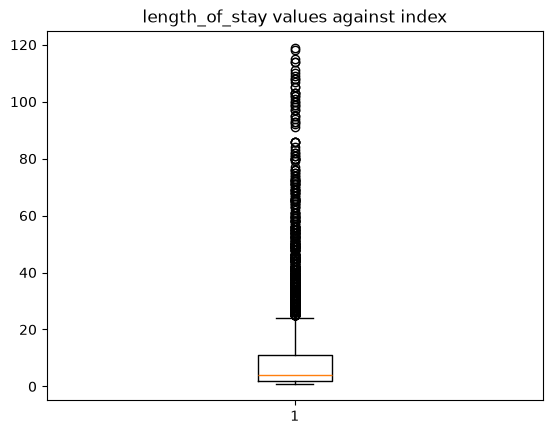

In [96]:
plots_to_make_numerical = ["birth_weight", "length_of_stay"]
for i in plots_to_make_numerical:
    col = pd.to_numeric(db[i], errors='coerce').dropna()
    plt.boxplot(col)
    plt.title(f"{i} values against index")
    plt.show()

In [97]:
codes_features = ["ccs_diagnosis_code", "ccs_procedure_code", "apr_drg_code", "apr_mdc_code"]
for i in codes_features:
    print(f"Unique categories in {i}: {db[i].nunique()}")


Unique categories in ccs_diagnosis_code: 220
Unique categories in ccs_procedure_code: 145
Unique categories in apr_drg_code: 264
Unique categories in apr_mdc_code: 25


1. Scale Birth weight
2. One Hot Encode Features
3. Normalize birth weight column
4. Handle Codes features

## One hot encoding for the features with less number of unique categories

In [98]:
def one_hot_encoder(df_list: list):
    encoder = OneHotEncoder(dtype=int, sparse_output=False).set_output(transform="pandas")
    df_transformed = pd.DataFrame()
    for i in df_list:
        if isinstance(db[[i]],pd.DataFrame):
           result = encoder.fit_transform(db[[i]])
           df_transformed = pd.concat([df_transformed,result], axis=1)
    return df_transformed
    
encoders_needed_with_one_hot = [
    "health_service_area",
    "age_group",
    "gender",
    "race",
    "type_of_admission",
    "patient_disposition",
    "ccs_diagnosis_code",
    "ccs_procedure_code",
    "apr_drg_code",
    "apr_mdc_code",
    "apr_severity_of_illness_code",
    "apr_risk_of_mortality",
    "abortion_edit_indicator",
    "emergency_department_indicator"
]
encoders_needed_with_label_encoding = ["ccs_diagnosis_code", "ccs_procedure_code", "apr_drg_code", "apr_mdc_code"]
df1 = one_hot_encoder(encoders_needed_with_one_hot)
df1.head()

,health_service_area_New York City,age_group_0 to 17,age_group_18 to 29,age_group_30 to 49,age_group_50 to 69,age_group_70 or Older,gender_F,gender_M,race_Black/African American,race_Other Race,...,apr_severity_of_illness_code_2,apr_severity_of_illness_code_3,apr_severity_of_illness_code_4,apr_risk_of_mortality_Extreme,apr_risk_of_mortality_Major,apr_risk_of_mortality_Minor,apr_risk_of_mortality_Moderate,abortion_edit_indicator_N,emergency_department_indicator_N,emergency_department_indicator_Y
0,1,0,0,1,0,0,0,1,0,1,...,0,0,0,0,0,1,0,1,0,1
1,1,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,1,0,1,0,1
2,1,1,0,0,0,0,0,1,0,1,...,1,0,0,0,0,1,0,1,0,1
3,1,0,0,1,0,0,1,0,1,0,...,0,0,0,0,0,1,0,1,0,1
4,1,1,0,0,0,0,1,0,0,1,...,0,0,0,0,0,1,0,1,0,1


## Target Encoding for features with multiple unique categories

In [99]:
def target_encoder(df_list: list):
    encoder = TargetEncoder(smooth="auto", cv=5).set_output(transform="pandas")
    y = pd.to_numeric(db["length_of_stay"].astype(str).str.replace("+", "", regex=False).str.strip(), errors='coerce')
    y = y.fillna(y.median()) 
    df_transformed = pd.DataFrame()
    for i in df_list:
        if isinstance(db[[i]], pd.DataFrame):
           result = encoder.fit_transform(db[[i]], y)
           df_transformed = pd.concat([df_transformed,result], axis=1)
    return df_transformed
    
encoders_needed_with_label_encoding = ["ccs_diagnosis_code", "ccs_procedure_code", "apr_drg_code", "apr_mdc_code"]
df2 = target_encoder(encoders_needed_with_label_encoding)
df2.head()

c:\Users\ApoorvTripathi\Desktop\length-of-stay-prediction-using-icp-codes\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ApoorvTripathi\Desktop\length-of-stay-prediction-using-icp-codes\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ApoorvTripathi\Desktop\length-of-stay-prediction-using-icp-codes\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\ApoorvTripathi\Desktop\length-of-stay-prediction-using-icp-codes\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,ccs_diagnosis_code_1,ccs_diagnosis_code_2,ccs_diagnosis_code_3,ccs_diagnosis_code_4,ccs_diagnosis_code_5,ccs_diagnosis_code_6,ccs_diagnosis_code_7,ccs_diagnosis_code_8,ccs_diagnosis_code_9,ccs_diagnosis_code_10,...,apr_mdc_code_107,apr_mdc_code_108,apr_mdc_code_109,apr_mdc_code_110,apr_mdc_code_111,apr_mdc_code_114,apr_mdc_code_115,apr_mdc_code_118,apr_mdc_code_119,apr_mdc_code_120
0,0.030078,0.132673,0.146114,0.060135,0.041462,0.038338,0.037296,0.044527,0.041416,0.039333,...,0.0,0.000438,0.000438,0.000438,0.0,0.000438,0.0,0.000000,0.000438,0.010959
1,0.037185,0.126362,0.135891,0.057357,0.033985,0.038212,0.036085,0.044552,0.037130,0.044521,...,0.0,0.000435,0.000435,0.000435,0.0,0.000436,0.0,0.000435,0.000000,0.011322
2,0.506813,0.225173,0.122076,0.042859,0.030576,0.018346,0.018336,0.006127,0.000000,0.006123,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.002328
3,0.024808,0.119651,0.144398,0.062533,0.047422,0.038788,0.038780,0.041998,0.037689,0.044116,...,0.0,0.000438,0.000438,0.000438,0.0,0.000438,0.0,0.000000,0.000438,0.010959
4,0.446606,0.265112,0.127263,0.057980,0.040530,0.017392,0.023150,0.005807,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.002328


### Creating Final DF

In [100]:
dfFinal = pd.concat([df1,df2], axis=1)
dfFinal.shape

(10000, 1122)

In [101]:
dfFinal.to_csv("data/transformed.csv", index=False)